In [8]:
import random
import operator
import math
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools

### Configuration variables

In [9]:
# Note: The following parameters can be adjusted to change the behavior of the PSO algorithm.
# Number of dimensions in each particle's position vector.
NUM_DECISION_VARIABLES = 20

# Number of particles in the swarm and optimization iterations.
POPULATION_SIZE = 50
NUM_OF_GEN = 1000

# Bound each velocity component to keep particle movement stable.
VELOCITY_MIN = -3
VELOCITY_MAX = 3

# Bound each decision variable within the search space.
POS_MIN = -30
POS_MAX = 30

# Note: From here you can change the objective function to optimize by changing the EVALUATION_FUNC_NAME variable to one of the following:
# evaluation_griewank, evaluation_rosenbrock
# Select the objective function.
EVALUATION_FUNC_NAME = "evaluation_griewank"

# Acceleration coefficients in the PSO update.
PHI1_CONSTANT = 1.49618
PHI2_CONSTANT = 1.49618

# Controls how much of the previous velocity carries into the next update.
INERTIA_WEIGHT = 0.7298

### Helper functions

In [10]:
# Create a particle with a random position and velocity in the search bounds.
def generate_particle(size, pos_min, pos_max, vel_min, vel_max):
    particle = creator.Particle(random.uniform(pos_min, pos_max) for _ in range(size))
    particle.velocity = [random.uniform(vel_min, vel_max) for _ in range(size)]
    particle.vel_min = vel_min
    particle.vel_max = vel_max
    return particle


def update_particle(particle, best, phi_1, phi_2, inertia_weight):
    # Draw independent random acceleration factors for each dimension.
    u1 = (random.uniform(0, phi_1) for _ in range(len(particle)))
    u2 = (random.uniform(0, phi_2) for _ in range(len(particle)))

    # The cognitive term pulls the particle toward its personal best.
    cognitive_component = map(
        operator.mul,
        u1,
        map(operator.sub, particle.best, particle)
    )

    # The social term pulls the particle toward the swarm's global best.
    social_component = map(
        operator.mul,
        u2,
        map(operator.sub, best, particle)
    )

    # Combine inertia, personal experience, and swarm experience to update velocity.
    particle.velocity = list(map(
        operator.add,
        (inertia_weight * velocity for velocity in particle.velocity),
        map(operator.add, cognitive_component, social_component)
    ))

    # Clip each velocity component so a particle cannot move too far in one step.
    for i, velocity in enumerate(particle.velocity):
        if abs(velocity) > particle.vel_max:
            particle.velocity[i] = math.copysign(
                particle.vel_max, velocity
            )

    # Move the particle using its newly calculated velocity.
    particle[:] = list(map(
        operator.add,
        particle,
        particle.velocity
    ))

    # Clip each position component to the permitted search space.
    for i, position in enumerate(particle):
        if position < POS_MIN:
            particle[i] = POS_MIN
        elif position > POS_MAX:
            particle[i] = POS_MAX


# Evaluate a particle using the selected objective function.
def evaluation_rosenbrock(individual):
    fitness = sum(
        100 * (individual[i] ** 2 - individual[i + 1]) ** 2
        + (individual[i] - 1) ** 2
        for i in range(len(individual) - 1)
    )
    return (fitness,)


def evaluation_griewank(individual):
    sum_part = sum(
        x ** 2 / 4000
        for x in individual
    )

    product_part = math.prod(
        math.cos(x / math.sqrt(i + 1))
        for i, x in enumerate(individual)
    )

    fitness = sum_part - product_part + 1

    return (fitness,)

### Toolbox

In [11]:
# Define a minimization fitness and the particle data structure.
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Particle", list, fitness=creator.FitnessMin, velocity=list, vel_min=None, vel_max=None, best=None)

# Register the particle factory and PSO operations with the DEAP toolbox.
toolbox = base.Toolbox()

toolbox.register("particle",
                 generate_particle,
                 size=NUM_DECISION_VARIABLES,
                 pos_min=POS_MIN,
                 pos_max=POS_MAX,
                 vel_min=VELOCITY_MIN,
                 vel_max=VELOCITY_MAX)

# Build a swarm by repeatedly calling the particle factory.
toolbox.register("population", tools.initRepeat, list, toolbox.particle)

# Bind the PSO coefficients to the particle update function.
toolbox.register("update",
                 update_particle,
                 phi_1=PHI1_CONSTANT,
                 phi_2=PHI2_CONSTANT,
                 inertia_weight=INERTIA_WEIGHT)

# Register the selected objective function.
EVALUATION_FUNCTIONS = {
    "evaluation_rosenbrock": evaluation_rosenbrock,
    "evaluation_griewank": evaluation_griewank
}

toolbox.register("evaluate", EVALUATION_FUNCTIONS[EVALUATION_FUNC_NAME])

/opt/anaconda3/lib/python3.13/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/opt/anaconda3/lib/python3.13/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'Particle' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


### PSO Algo Implementation

In [12]:
# Run PSO for each seed.
seed_list = list(range(1, 31))
results = []
convergence_data = []

for seed in seed_list:
    random.seed(seed)
    population = toolbox.population(POPULATION_SIZE)
    best = None
    best_fitness_by_generation = []

    for gen in range(NUM_OF_GEN):
        # Evaluate particles and update their bests.
        for part in population:
            part.fitness.values = toolbox.evaluate(part)

            if not part.best or part.best.fitness < part.fitness:
                part.best = creator.Particle(part)
                part.best.fitness.values = part.fitness.values

            if not best or best.fitness < part.fitness:
                best = creator.Particle(part)
                best.fitness.values = part.fitness.values

        # Record the swarm's best fitness.
        best_fitness_by_generation.append(best.fitness.values[0])

        # Move particles using the global best.
        for part in population:
            toolbox.update(part, best)

    results.append({
        "seed": seed,
        "best_solution": list(best),
        "fitness": best.fitness.values[0]
    })
    convergence_data = best_fitness_by_generation
    print(
        f"Seed: {seed}, function: {EVALUATION_FUNC_NAME}, number_of_decisions: {NUM_DECISION_VARIABLES}, "
        f"Best fitness: {best.fitness.values[0]}"
    )

Seed: 1, function: evaluation_griewank, number_of_decisions: 20, Best fitness: 0.0
Seed: 2, function: evaluation_griewank, number_of_decisions: 20, Best fitness: 0.01231607251926159
Seed: 3, function: evaluation_griewank, number_of_decisions: 20, Best fitness: 0.05886734915439451
Seed: 4, function: evaluation_griewank, number_of_decisions: 20, Best fitness: 0.014772407722822956
Seed: 5, function: evaluation_griewank, number_of_decisions: 20, Best fitness: 0.00985728460782076
Seed: 6, function: evaluation_griewank, number_of_decisions: 20, Best fitness: 0.00985728460782076
Seed: 7, function: evaluation_griewank, number_of_decisions: 20, Best fitness: 0.03446240416099133
Seed: 8, function: evaluation_griewank, number_of_decisions: 20, Best fitness: 0.007396040334114895
Seed: 9, function: evaluation_griewank, number_of_decisions: 20, Best fitness: 0.054083775159193714
Seed: 10, function: evaluation_griewank, number_of_decisions: 20, Best fitness: 0.00985728460782076
Seed: 11, function: ev

In [13]:
# Summarize final fitness across seeds.
fitness_values = [result["fitness"] for result in results]

mean_fitness = np.mean(fitness_values)
std_fitness = np.std(fitness_values, ddof=1)

print("Mean:", mean_fitness)
print("Std:", std_fitness)

Mean: 0.01787577137236708
Std: 0.01719203705800012


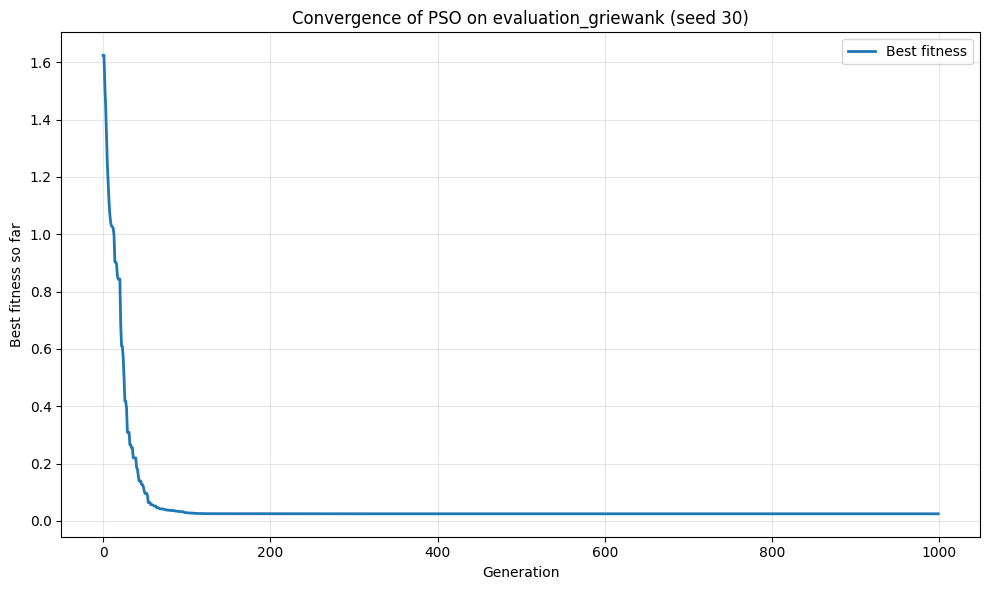

In [14]:
# Plot the latest seed's convergence.
generations = np.arange(len(convergence_data))

plt.figure(figsize=(10, 6))
plt.plot(generations, convergence_data, label="Best fitness", linewidth=2)
plt.xlabel("Generation")
plt.ylabel("Best fitness so far")
plt.title(f"Convergence of PSO on {EVALUATION_FUNC_NAME} (seed {seed_list[-1]})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()